In [17]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [18]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
"""vep_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1


In [19]:
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/annotation_files/genebass352genes_olink371genes_annotated_251205.parquet -o /home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205.parquet

# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/annotation_files/genebass352genes_olink371genes_annotated_251205_fillna.parquet -o /home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/annotations_fillna_ukbgym.parquet -o /home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet

Error: path "/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet"
already exists but -f/--overwrite was not set


In [20]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")

min_range = -2000
max_range = +0

anno = (
    anno
    .filter(
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # filter_expression &

        # Choose regulatory region
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &
        
        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    # .with_columns(
    #     core_promoter = pl.col('dist_to_tss').abs() <= 50,
    #     encode_annotated = pl.col('not_in_encode') == False,
    #     encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
    #     encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca_tf']),
    # )
    .with_columns(
        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_lip_full']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        # set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
        set(['id', 'region']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

loftee_lip,verphylop,consequence_splice_acceptor_variant,promoterai,loftee_disorder,consequence_splice_donor_variant,consequence_start_lost,am_pathogenicity,absplice2_max,five_prime_utr_variant_consequence_ustop_lost,score_pai3d,ted_domain,gpn_score,loftee_lc,cadd_raw,loftee_low_complexity,esmscoremissense,absplice_dna_max,abexp_abs_max,delta_score,consequence_synonymous_variant,mobi_curated_disorder_priority,mobi_lip_full,consequence_stop_lost,id,loftee_ted,consequence_missense_variant,pangolin_score,consequence_stop_gained,loftee_hc,five_prime_utr_variant_consequence_uaug_gained,consequence_frameshift_variant,region,low_complexity_domain,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_ustop_gained
bool,f32,i8,f32,bool,i8,i8,f32,f32,u8,f32,bool,f32,i8,f32,bool,f32,f32,f32,f32,i8,bool,bool,i8,str,bool,i8,f32,i8,i8,u8,i8,str,bool,u8,u8
false,-0.414,0,-0.0076,false,0,0,0.2235,0.000313,0,0.167139,false,-1.03,0,-0.605587,false,-1.347,0.003,0.006261,0.0,0,false,false,0,"""chr19:17405457:G:A""",false,1,0.05,0,0,0,0,"""ENSG00000130303""",true,0,0
false,0.873,0,0.004,false,0,0,0.1417,0.000034,0,0.523556,false,-5.1,0,4.228296,false,-4.801,0.0,0.016074,0.02,0,false,false,0,"""chr15:42736599:C:A""",false,1,0.01,0,0,0,0,"""ENSG00000140326""",false,0,0
false,8.752,0,0.0,false,0,0,0.9693,0.000347,0,0.0,true,-10.31,0,4.197816,false,-7.779,0.003,0.083404,0.01,0,false,false,0,"""chr4:121820711:T:G""",false,1,0.01,0,0,0,0,"""ENSG00000145386""",false,0,0
false,7.324,0,0.0,false,0,0,0.9435,0.000341,0,0.621906,true,-11.14,0,5.248696,false,-12.769,0.003,0.079256,0.0,0,false,true,0,"""chr9:35101207:C:T""",false,1,0.0,0,0,0,0,"""ENSG00000165283""",false,0,0
false,4.056,0,-0.0066,false,0,0,0.4478,0.000329,0,0.0,false,-8.24,0,3.200126,false,-8.268,0.003,0.088004,0.06,0,true,false,0,"""chr10:121515138:G:C""",false,1,0.01,0,0,0,0,"""ENSG00000066468""",false,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
false,4.039,0,0.0,false,0,0,0.6021,0.000327,0,0.621652,true,-6.76,0,4.232519,false,-3.162,0.003,0.088004,0.0,0,false,false,0,"""chr7:108194412:C:T""",false,1,0.0,0,0,0,0,"""ENSG00000091129""",false,0,0
false,5.509,0,0.0,false,0,0,0.5548,0.002855,0,0.0,true,-10.94,0,4.479037,false,-9.695,0.01,0.34215,0.27,0,false,false,0,"""chr7:88131405:A:T""",false,1,0.22,0,0,0,0,"""ENSG00000008277""",false,0,0
false,7.511,0,0.0,false,0,0,0.1431,0.000321,0,0.0,true,-9.73,0,4.513728,false,-5.893,0.002861,0.088004,0.0,0,false,false,0,"""chr1:160093779:G:C""",false,1,0.0,0,0,0,0,"""ENSG00000162729""",false,0,0


In [21]:
selected_annos = anno_config_df.filter(
    # pl.col('category').is_in(['vep_consequences']) # VEP CDS consequences
    # pl.col('category').is_in(['plof_consequences']) # VEP plof consequences
    # (pl.col('category').is_in(['plof', 'missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'])) # CDS
    (pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation'])) # missense
    # (pl.col('category').is_in(['protein_domains'])) # protein domains
    # (pl.col('category').is_in(['loftee_protein_domains'])) # protein domains
    # (pl.col('category').is_in(['splicing', 'genetic_diversity', 'conservation'])) # synonymous

    # (pl.col('category').is_in(['splicing', 'conservation', 'regulatory_nondir', 'genetic_diversity'])) # non coding
    # (pl.col('category').is_in(['encode_regions'])) # encode regions
    # (pl.col('category').is_in(['encode_custom'])) # encode regions custom
    # (pl.col('category').is_in(['conservation', 'regulatory_nondir', 'genetic_diversity'])) # 5UTR
)['annotation'].to_list()

melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr19:17405457:G:A""","""ENSG00000130303""","""cadd_raw""",-0.605587
"""chr15:42736599:C:A""","""ENSG00000140326""","""cadd_raw""",4.228296
"""chr4:121820711:T:G""","""ENSG00000145386""","""cadd_raw""",4.197816
"""chr9:35101207:C:T""","""ENSG00000165283""","""cadd_raw""",5.248696
"""chr10:121515138:G:C""","""ENSG00000066468""","""cadd_raw""",3.200126
…,…,…,…
"""chr7:108194412:C:T""","""ENSG00000091129""","""verphylop""",4.039
"""chr7:88131405:A:T""","""ENSG00000008277""","""verphylop""",5.509
"""chr1:160093779:G:C""","""ENSG00000162729""","""verphylop""",7.511


In [22]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet

appv = pl.scan_parquet("/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrela
ted_appv_percentiles.parquet" already exists but -f/--overwrite was not set


In [26]:
# Get gene trait associations
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_lofteeHC_mac20.parquet -o /home/dnanexus/data_dir/
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/loftee_mac20_associations_bh_corrected.parquet -o /home/dnanexus/data_dir/

gene_trait_df = pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20.parquet')

gene_trait_df = (
    gene_trait_df
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'effect'])
)
gene_trait_df

dxpy.utils.resolver.ResolutionError: Unable to resolve "regenie_127phenotypes_lofteeHC_mac20.parquet" to a data object or folder name in '/processed_data/REGENIE_results'


region,phenotype,effect
str,str,f64
"""ENSG00000132855""","""apolipoprotein_a_int""",-0.46207
"""ENSG00000052841""","""apolipoprotein_a_int""",-0.807306
"""ENSG00000110243""","""apolipoprotein_a_int""",-0.449444
"""ENSG00000118137""","""apolipoprotein_a_int""",-2.60164
"""ENSG00000173064""","""apolipoprotein_a_int""",-0.873767
…,…,…
"""ENSG00000182095""","""forced_expiratory_volume_in_1s…",-0.860502
"""ENSG00000164741""","""forced_expiratory_volume_in_1s…",-0.642983
"""ENSG00000205189""","""forced_expiratory_volume_in_1s…",-0.635227


In [27]:
gene_trait_df['region'].n_unique(), gene_trait_df.shape[0]

(699, 2289)

In [30]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- 2. Build the main lazy query plan step-by-step ---
# Start by filtering 'appv', then join everything together. Every operation returns another LazyFrame.
final_lazy_plan = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    .join(anno_ids_lazy, on="id", how="semi")

    # B. Join the other two dataframes
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )

    # C. Apply the ranking (window function) lazily
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    # D. Apply the group_by and aggregation lazily
    # .group_by(["region", "gene_name", "phenotype", "annotation"])
    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
    )
)

# --- 3. Execute the ENTIRE plan at once ---
# This is the ONLY time data is computed. The streaming engine handles the whole complex query in memory-safe chunks.
print("Executing the full lazy plan with the streaming engine...")
correlation_df = final_lazy_plan.collect(engine='streaming')
correlation_df

Executing the full lazy plan with the streaming engine...


region,phenotype,annotation,n_variants,correlation
str,str,str,u64,f64
"""ENSG00000168769""","""haemoglobin_concentration_int""","""esmscoremissense""",979,-0.034281
"""ENSG00000196235""","""reticulocyte_percentage_int""","""am_pathogenicity""",390,-0.029364
"""ENSG00000140470""","""forced_expiratory_volume_in_1s…","""cadd_raw""",680,-0.087152
"""ENSG00000165124""","""diastolic_blood_pressure_autom…","""cadd_raw""",1489,-0.021207
"""ENSG00000178177""","""leg_predicted_mass_right_int""","""am_pathogenicity""",790,0.028102
…,…,…,…,…
"""ENSG00000119707""","""standing_height_int""","""gpn_score""",275,0.1168
"""ENSG00000137834""","""seated_height_int""","""score_pai3d""",355,-0.050953
"""ENSG00000150961""","""trunk_fatfree_mass_int""","""score_pai3d""",385,-0.061911


In [ ]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_mac20.parquet -o /home/dnanexus/data_dir/association_files/

loftee_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_mac20.parquet')
    .select(['region', 'phenotype', 'loftee_correlation', 'loftee_corr_dir']) 
)

loftee_corrs

Error: path "/home/dnanexus/data_dir/association_files/loftee_correlation_quan
titative_wgs_EUR_genebass1e6_mac20.parquet" already exists but -f/--overwrite
was not set


region,phenotype,loftee_correlation,loftee_corr_dir
str,str,f64,f64
"""ENSG00000130164""","""ldl_direct_int""",0.116846,1.0
"""ENSG00000107863""","""trunk_predicted_mass_int""",-0.13247,-1.0
"""ENSG00000171295""","""vitamin_d_int""",0.107987,1.0
"""ENSG00000137834""","""forced_vital_capacity_fvc_best…",-0.085975,-1.0
"""ENSG00000166819""","""reticulocyte_percentage_int""",-0.061248,-1.0
…,…,…,…
"""ENSG00000100345""","""high_light_scatter_reticulocyt…",-0.076141,-1.0
"""ENSG00000166278""","""albumin_int""",-0.008141,-1.0
"""ENSG00000073060""","""hdl_cholesterol_int""",0.13731,1.0


In [24]:
# --- 4. Join with beta directions and annotation directions ---
correlation_df = (
    correlation_df
    .filter(pl.col('annotation')!='loftee_hc')
    .select(["region", "gene_name", "phenotype", "annotation", "n_variants", "correlation"])
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        loftee_corrs, 
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_correlation'))*pl.col('loftee_corr_dir')
    )
)
print("Final DataFrame shape:", correlation_df.shape)
correlation_df

NameError: name 'correlation_df' is not defined

In [12]:
# correlation_df.write_parquet(f'/home/dnanexus/data_dir/results/correlations_all_vars_wgs_EUR_genebass1e6_maf1e3.parquet')
# correlation_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/correlations_all_vars_wgs_EUR_genebass1e6_maf1e3.parquet')

In [13]:

consistent_gt = (
    correlation_df
    # .filter(pl.col('annotation')!='promoterai_abs')
    .drop_nulls().drop_nans()
    .group_by(['region', 'gene_name', 'phenotype'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10)  # Select genes with more than 10 variants
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'gene_name', 'phenotype'], how='inner')
filt_corr_df

region,gene_name,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,loftee_correlation,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,u64
"""ENSG00000080031""","""PTPRH""","""platelet_count_int""","""esmscoremissense""",519,0.000554,"""#feb72d""","""ESM1v""",-1,-0.02644,-1.0,0.000554,0.020953,7
"""ENSG00000080345""","""RIF1""","""waist_circumference_int""","""gpn_score""",1043,-0.052298,"""#942c80""","""GPN-MSA""",-1,0.019213,1.0,0.052298,2.722059,7
"""ENSG00000117139""","""KDM5B""","""hand_grip_strength_right_int""","""am_pathogenicity""",771,-0.097649,"""#feb72d""","""AlphaMissense""",1,-0.108459,-1.0,0.097649,0.900329,7
"""ENSG00000096968""","""JAK2""","""platelet_count_int""","""score_pai3d""",561,0.265479,"""#feb72d""","""PrimateAI-3D""",1,0.193976,1.0,0.265479,1.368616,7
"""ENSG00000170471""","""RALGAPB""","""peak_expiratory_flow_pef_int""","""verphylop""",532,-0.01354,"""#942c80""","""Vertebrate PhyloP""",1,-0.116537,-1.0,0.01354,0.116188,7
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000166603""","""MC4R""","""arm_fatfree_mass_right_int""","""am_pathogenicity""",135,0.028619,"""#feb72d""","""AlphaMissense""",1,0.18153,1.0,0.028619,0.157656,7
"""ENSG00000156515""","""HK1""","""glycated_haemoglobin_hba1c_int""","""score_pai3d""",357,-0.252276,"""#feb72d""","""PrimateAI-3D""",1,-0.080897,-1.0,0.252276,3.118503,7
"""ENSG00000010327""","""STAB1""","""ldl_direct_int""","""cadd_raw""",1234,0.047221,"""#1f77b4""","""CADD Raw""",1,0.037548,1.0,0.047221,1.257605,7


In [14]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'gene_name', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


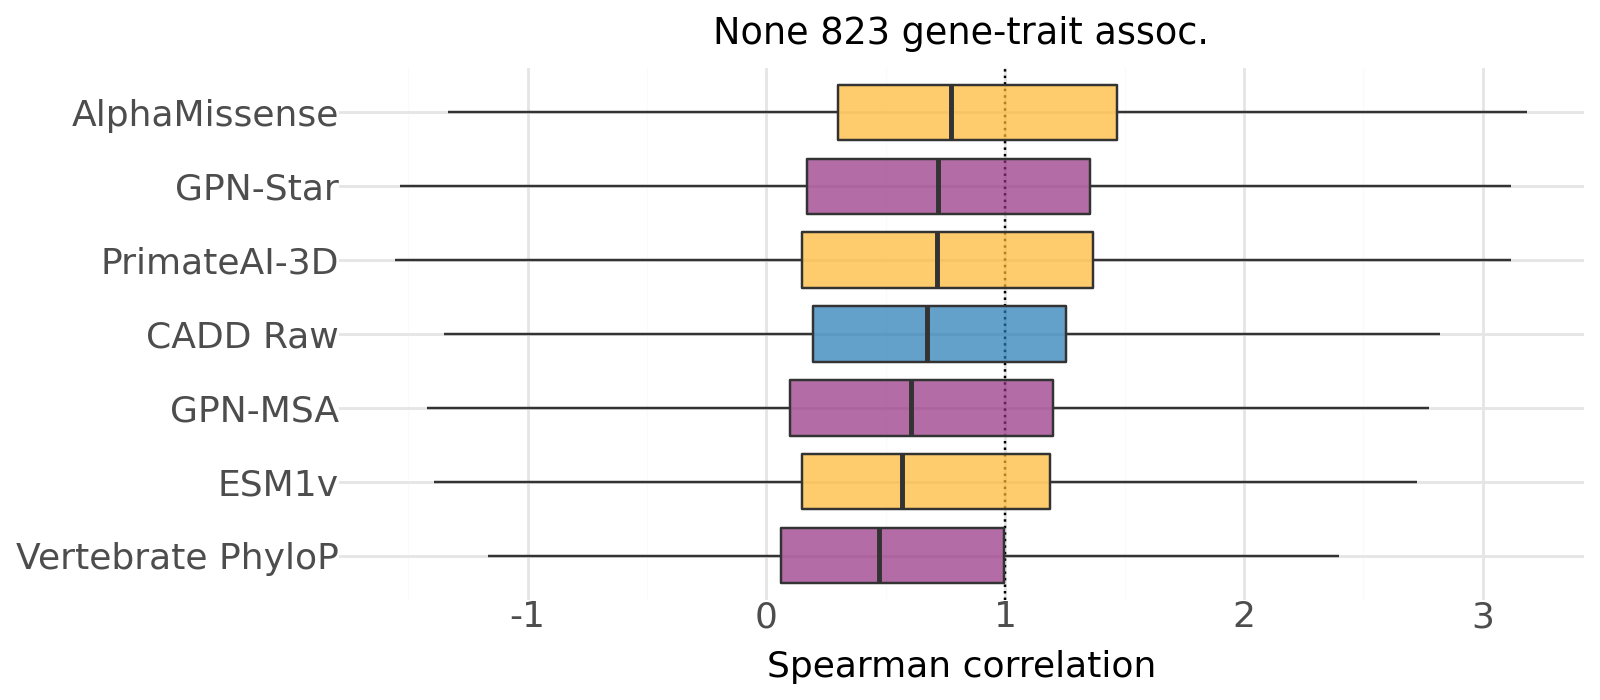

In [20]:
# Prepare for plotting
med_df = filt_corr_df.drop_nans().group_by("annotation").agg(
    median_corr_beta_rescaled = pl.col("corr_beta_rescaled").median(),
)

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_corr_beta_rescaled', ascending=True)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="label", y="corr_beta_rescaled", fill="annotation"))
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{pheno_list_type} {corr_pd[['region', 'phenotype']].drop_duplicates().shape[0]} gene-trait assoc."
        # \nGene body ±5kb"
        # \n VEP CDS variants"
        # \n Disorder region missense variants"
        # \n{variant_class} variants"
        # \nTSS [{min_range}bp, {max_range}bp]"
    )
    + coord_flip()
    + theme(
        # figure_size=(8, 5),
        figure_size=(8, 3.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [16]:
med_df.sort('median_corr_beta_rescaled')

annotation,median_corr_beta_rescaled
str,f64
"""verphylop""",0.47103
"""esmscoremissense""",0.566861
"""gpn_score""",0.606769
"""cadd_raw""",0.672089
"""score_pai3d""",0.713374
"""gpn_star_llr_calibrated_mean""",0.719884
"""am_pathogenicity""",0.774865


In [17]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_242140/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""am_pathogenicity""","""verphylop""",823,65830.0,3.4174e-52
"""verphylop""","""cadd_raw""",823,72435.0,5.6337e-46
"""verphylop""","""gpn_star_llr_calibrated_mean""",823,75194.0,1.6896e-43
"""verphylop""","""score_pai3d""",823,80602.0,7.5506e-39
"""gpn_score""","""gpn_star_llr_calibrated_mean""",823,88260.0,9.9707e-33
…,…,…,…,…
"""score_pai3d""","""gpn_star_llr_calibrated_mean""",823,139423.0,0.00001
"""am_pathogenicity""","""score_pai3d""",823,144843.0,0.000295
"""cadd_raw""","""gpn_star_llr_calibrated_mean""",823,150337.0,0.004884


In [18]:
stats_df.filter(
    (pl.col('VSM_A') == 'absplice2_max') | (pl.col('VSM_B') == 'absplice2_max')
)

VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
